Digite o valor inicial de x0 (ex: -2): 6
Digite o valor inicial de y0 (ex: 3): 87

Iniciando Método: STEEPEST
------------------------------------------------------------
Iter:  0 | (x, y): ( 6.0000, 87.0000) | f: -14118.0000 | h:  0.0000 | erro: 3.73888e+02
Iter:  1 | (x, y): (37.5874, 22.2843) | f: -655.6008 | h:  0.1926 | erro: 3.18318e+01
Iter:  2 | (x, y): ( 2.1863,  5.0052) | f: -28.6260 | h:  1.2375 | erro: 1.74128e+01
Iter:  3 | (x, y): ( 3.6574,  1.9913) | f:  0.5737 | h:  0.1926 | erro: 1.48248e+00
Iter:  4 | (x, y): ( 2.0087,  1.1865) | f:  1.9336 | h:  1.2375 | erro: 8.10954e-01
Iter:  5 | (x, y): ( 2.0772,  1.0462) | f:  1.9969 | h:  0.1926 | erro: 6.90425e-02
Iter:  6 | (x, y): ( 2.0004,  1.0087) | f:  1.9999 | h:  1.2375 | erro: 3.77680e-02
Iter:  7 | (x, y): ( 2.0036,  1.0022) | f:  2.0000 | h:  0.1926 | erro: 3.21547e-03
Iter:  8 | (x, y): ( 2.0000,  1.0004) | f:  2.0000 | h:  1.2375 | erro: 1.75894e-03
Iter:  9 | (x, y): ( 2.0002,  1.0001) | f:  2.0000 | h:  0.1926 | 

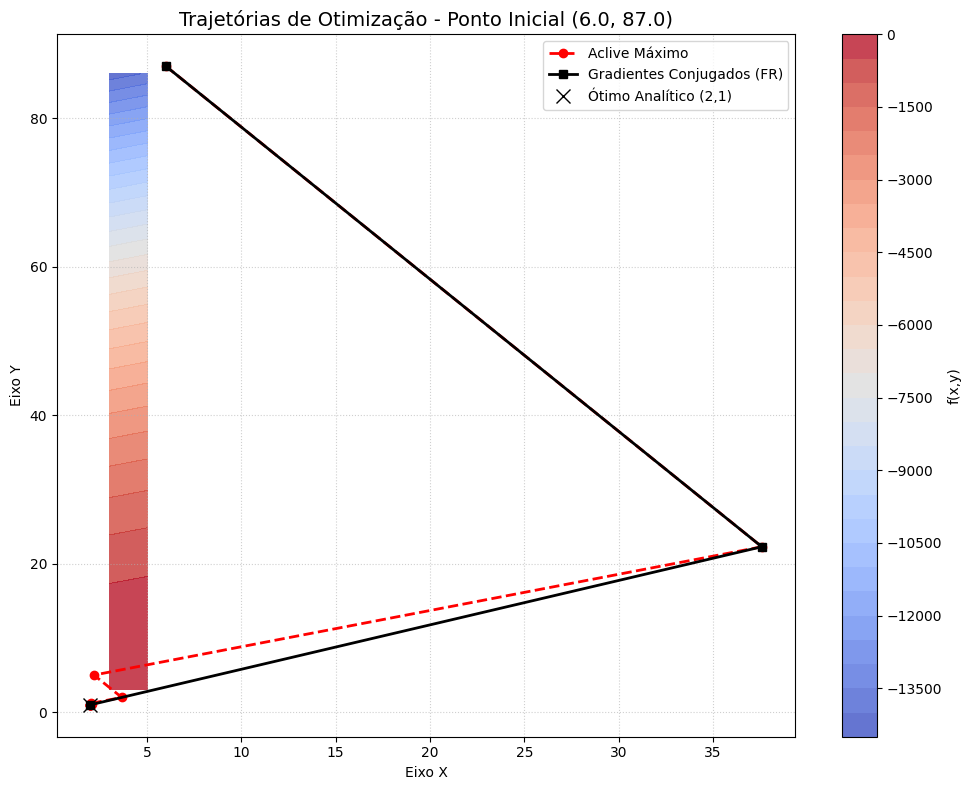

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


################### PROGRAMA PARA CASA 4 ######################
###############################################################
### Aluno: LUIZ FELIPE THEODORO CARNEIRO                    ###
### Matricula: 200023349                                    ###
###############################################################

'''
Exercício de otimização para entender na prática a diferença entre métodos de busca locais.
'''

'''
Como a função objetivo f(x,y) = 2xy + 2x - (x)^2 - 2(y)^2 é uma superfície quadrática exata,
a interpolação parabólica de 3 pontos tem como objetivo localizar o ótimo unidimensional ao longo da direção de busca
em um único passo, sem a necessidade de um laço iterativo dentro da busca em linha.
'''

# ---------------------------------------------------------
# 1. Definições da Função e do Gradiente
# ---------------------------------------------------------
def f(x, y): # cria a função objetivo computacional baseada na formula
    """Função objetivo a ser maximizada."""
    return 2*x*y + 2*x - x**2 - 2*y**2

def grad_f(x, y): # calcula e retorna o gradiente analítico $\nabla f$ utilizando o módulo numpy para construir um vetor matemático.
    """Vetor gradiente da função objetivo."""
    dfx = 2*y + 2 - 2*x
    dfy = 2*x - 4*y
    return np.array([dfx, dfy])

# Este vetor aponta sempre para a direção de maior crescimento em qualquer ponto isolado da superfície.

# ---------------------------------------------------------
# 2. Busca Unidimensional (Interpolação Quadrática)
# ---------------------------------------------------------
'''
Para um ponto (x,y) e um vetor direcional dado (px, py),
foram selecionados três multiplicadores hipotéticos (h_0 = 0.0, h_1 = 0.1, h_2 = 0.2)
e calculado o valor da função g(h) nessas localizações ao longo da linha.
'''
def line_search(x, y, px, py): # Este método calcula a amplitude ideal do passo (fator h*).
    """Encontra o passo ótimo h* ao longo da direção (px, py)."""
    # Escolha de três pontos arbitrários e distintos para h
    h0, h1, h2 = 0.0, 0.1, 0.2

    # Função g(h) ao longo da direção de busca
    g0 = f(x + h0*px, y + h0*py)
    g1 = f(x + h1*px, y + h1*py)
    g2 = f(x + h2*px, y + h2*py)

    # Fórmula do vértice (interpolação quadrática de 3 pontos)
    num = (h0**2 - h2**2)*g1 + (h2**2 - h1**2)*g0 + (h1**2 - h0**2)*g2
    den = (h0 - h2)*g1 + (h2 - h1)*g0 + (h1 - h0)*g2
    '''
    Com isso, montou-se o polinômio aplicando a fórmula do vértice ensinada
    no material para encontrar o máximo da parábola e isolar h*.
    '''
    # Prevenção contra parábola degenerada (denominador próximo a zero)
    if abs(den) < 1e-12:
        hs = [h0, h1, h2]
        gs = [g0, g1, g2]
        '''
        testamos se a diferença for nula (den < 1e-12),
        escolhemos simplesmente o valor de h (entre os 3 testados)
        que gerou a maior pontuação em g(h).
        '''
        return hs[np.argmax(gs)] # Retorna o h que gerou o melhor resultado

    h_linha = 0.5 * (num / den)
    return h_linha

# ---------------------------------------------------------
# 3. Métodos de Otimização
# ---------------------------------------------------------
def optimize(x0, y0, method='steepest', tol=1e-5, max_iter=100):
    """Executa a otimização usando Aclive Máximo ou Fletcher-Reeves."""
    #Esta função abraça as dinâmicas dos dois algoritmos, iterando até 100 passos:
    x, y = x0, y0
    history = [(x, y)] # Guarda o caminho percorrido
    log = []           # Guarda os dados para o arquivo de saída

    px, py = 0.0, 0.0
    grad_prev = None
    h_val = 0.0

    print(f"\nIniciando Método: {method.upper()}")
    print("-" * 60)

    for i in range(max_iter):
        grad = grad_f(x, y)
        err = np.linalg.norm(grad) #O erro é definido pelo módulo do gradiente.
        '''
        O laço salva os resultados da iteração num buffer (log) de acordo com a formatação exigida.
        '''

        # O passo (h_val) referente ao cálculo anterior. No passo 0 é nulo.
        if i == 0:
            h_print = 0.0
        else:
            h_print = h_val

        # Armazena e imprime o log atual
        log.append(f"{i} {err:.6e} {h_print:.6f} {x:.6f} {y:.6f} {grad[0]:.6f} {grad[1]:.6f}\n")
        print(f"Iter: {i:2d} | (x, y): ({x:7.4f}, {y:7.4f}) | f: {f(x,y):7.4f} | h: {h_print:7.4f} | erro: {err:.5e}")

        # Critério de parada
        if err < tol:
            print("=> Convergência alcançada!")
            break

        # Definição da direção de busca com base no método
        # Usa inteiramente o próprio gradiente no ponto sem considerar o caminho anterior
        # Isso inevitavelmente causa ortogonalidade a cada duas buscas (fenômeno do zigue-zague).
        if method == 'steepest':
            px, py = grad[0], grad[1]
        # Salva o gradiente da etapa anterior e introduz o multiplicador conjugado B_k
        # A direção agora é uma combinação do "aclive" atual somado com uma inércia B vinda do passo anterior
        elif method == 'fletcher_reeves':
            if i == 0:
                px, py = grad[0], grad[1]
            else:
                beta = (np.linalg.norm(grad)**2) / (np.linalg.norm(grad_prev)**2)
                px = grad[0] + beta * px
                py = grad[1] + beta * py

        # Salva o gradiente atual para o próximo ciclo (necessário no FR)
        grad_prev = grad

        # Busca unidimensional e atualização das coordenadas
        '''
        Ao final do laço, atualizamos os vetores espaciais, somando x e y com
        a sua respectiva direção ponderada pelo passo unidimensional h.
        '''
        h_val = line_search(x, y, px, py)
        x = x + h_val * px
        y = y + h_val * py

        history.append((x, y))

    return history, log

# ---------------------------------------------------------
# 4. Execução Principal e I/O de Arquivos
# ---------------------------------------------------------
'''
pedimos ao usuário sua coordenada, passamos isso como alimento aos algoritmos e exportamos:
'''
if __name__ == "__main__":
    # Ponto inicial do usuário
    try:
        x0 = float(input("Digite o valor inicial de x0 (ex: -2): "))
        y0 = float(input("Digite o valor inicial de y0 (ex: 3): "))
    except ValueError:
        print("Valores inválidos, utilizando o padrão (-2, 3) conforme APC4.")
        x0, y0 = -2.0, 3.0

    # 4.1. Executar Métodos
    hist_sa, log_sa = optimize(x0, y0, method='steepest')
    hist_fr, log_fr = optimize(x0, y0, method='fletcher_reeves')

    # 4.2. Salvar Logs de Execução
    '''
    Criamos os relatórios output1.dat e output2.dat injetando neles o buffer que formamos no passo 3.
    A malha function.dat também é criada extraindo dados 100x100 do meshgrid do Numpy.
    '''
    with open("output1.dat", "w") as f_out:
        f_out.write("iter erro h x y dfx dfy\n")
        f_out.writelines(log_sa)

    with open("output2.dat", "w") as f_out:
        f_out.write("iter erro h x y dfx dfy\n")
        f_out.writelines(log_fr)

    # 4.3. Gerar Malha para Curvas de Nível e salvar function.dat
    x_vals = np.linspace(x0 - 1, 3, 100)
    y_vals = np.linspace(y0 - 1, 3, 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = f(X, Y)

    with open("function.dat", "w") as f_out:
        f_out.write("X Y F\n")
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                f_out.write(f"{X[i,j]:.4f} {Y[i,j]:.4f} {Z[i,j]:.4f}\n")

    # ---------------------------------------------------------
    # 5. Visualização (Gráfico)
    # ---------------------------------------------------------
    '''
    Alimentamos os históricos do percurso dentro de um contourf (Mapa de relevo plano) usando matplotlib.
    Como instruído, usamos marcações contrastantes (Vermelho e tracejado vs Preto contínuo) para que se observe
    perfeitamente o comportamento caótico do Aclive Máximo versus a trajetória polida do Fletcher-Reeves até o pico em (2,1).
    '''
    plt.figure(figsize=(10, 8))

    # Plota as curvas de nível
    contour = plt.contourf(X, Y, Z, levels=30, cmap='coolwarm', alpha=0.8)
    plt.colorbar(contour, label='f(x,y)')

    # Desempacota as coordenadas das trajetórias
    hx_sa, hy_sa = zip(*hist_sa)
    hx_fr, hy_fr = zip(*hist_fr)

    # Plota os caminhos percorridos
    plt.plot(hx_sa, hy_sa, 'r--o', label='Aclive Máximo', markersize=6, linewidth=2)
    plt.plot(hx_fr, hy_fr, 'k-s', label='Gradientes Conjugados (FR)', markersize=6, linewidth=2)

    # Plota o ótimo analítico exato (2, 1)
    plt.plot(2, 1, 'x', markersize=10, markeredgecolor='black', label='Ótimo Analítico (2,1)')

    plt.title(f"Trajetórias de Otimização - Ponto Inicial ({x0}, {y0})", fontsize=14)
    plt.xlabel('Eixo X')
    plt.ylabel('Eixo Y')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    # Salva e mostra o gráfico
    plt.tight_layout()
    plt.savefig("trajetorias.png", dpi=300)
    plt.show()